## Pneumonia Detection on X-RAY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

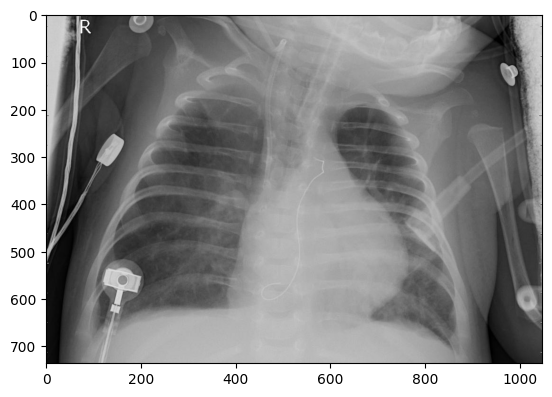

In [2]:
path = "/Users/baptistehernette/Documents/Pneumonia_detection/data/chest_xray/train/PNEUMONIA"
img = cv2.imread(os.path.join(path, os.listdir(path)[0]))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

/Users/baptistehernette/Documents/Pneumonia_detection/.venv_pneumo/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    "/Users/baptistehernette/Documents/Pneumonia_detection/data/chest_xray/train/",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.


In [6]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_generator = test_datagen.flow_from_directory(
    "/Users/baptistehernette/Documents/Pneumonia_detection/data/chest_xray/test/",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

Found 624 images belonging to 2 classes.


In [7]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_generator = val_datagen.flow_from_directory(
    "/Users/baptistehernette/Documents/Pneumonia_detection/data/chest_xray/val/",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

Found 16 images belonging to 2 classes.


In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

/Users/baptistehernette/Documents/Pneumonia_detection/.venv_pneumo/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/Users/baptistehernette/Documents/Pneumonia_detection/.venv_pneumo/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 353ms/step - accuracy: 0.7223 - loss: 1.1722 - val_accuracy: 0.5000 - val_loss: 2.3326
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 390ms/step - accuracy: 0.8524 - loss: 0.3344 - val_accuracy: 0.6250 - val_loss: 1.7220
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 378ms/step - accuracy: 0.8620 - loss: 0.3038 - val_accuracy: 0.6250 - val_loss: 1.1930
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 375ms/step - accuracy: 0.8832 - loss: 0.2765 - val_accuracy: 0.6250 - val_loss: 1.5338
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 378ms/step - accuracy: 0.8894 - loss: 0.2574 - val_accuracy: 0.6250 - val_loss: 1.3369
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 60s 368ms/step - accuracy: 0.8959 - loss: 0.2471 - val_accuracy: 0.6875 - val_loss: 1.0552
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 360ms/step - accuracy: 0.8874 - loss: 0.2559 - val_accuracy: 0.6250 - val_loss: 1.2718
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 386ms/step - accuracy: 0.8997 - loss: 0

| Metric                                       | Description                                                                                                       | How to Interpret                                                                                                                |
| -------------------------------------------- | ----------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| **Precision**                                | Out of all samples predicted as this class, how many are actually correct. <br>Formula: `TP / (TP + FP)`          | High precision → model makes **few false positive errors**. Useful when **false positives are costly**.                         |
| **Recall (Sensitivity, True Positive Rate)** | Out of all actual samples of this class, how many did the model correctly identify. <br>Formula: `TP / (TP + FN)` | High recall → model captures **most of the actual positives**. Useful when **missing a positive is costly**.                    |
| **F1-Score**                                 | Harmonic mean of precision and recall. <br>Formula: `2 * (Precision * Recall) / (Precision + Recall)`             | High F1 → **balance between precision and recall**. Important when both false positives and false negatives matter.             |
| **Support**                                  | Number of true occurrences of each class in the dataset.                                                          | Shows **how many samples** belong to each class. Helps interpret the reliability of metrics: low support → metrics less stable. |

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(test_generator)
print(classification_report(test_generator.classes, y_pred.round()))

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step
              precision    recall  f1-score   support

           0       0.40      0.09      0.14       234
           1       0.63      0.92      0.75       390

    accuracy                           0.61       624
   macro avg       0.51      0.50      0.44       624
weighted avg       0.54      0.61      0.52       624



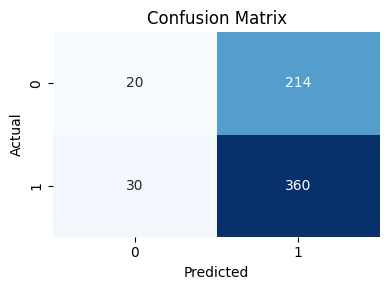

In [17]:
cm = confusion_matrix(test_generator.classes, y_pred.round())
labels = ["NORMAL", "PNEUMONIA"]

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
fig.tight_layout()
plt.show()

Huge amount of false positive (214 out of 624, 34%) meaning that we detecte pneumonia for patients that do not have any. Not very good but it is better than having to much false negative (30 out of 624, 5%) that is the case where patient have pneumonia but nothing is detected by the model.

### Imbalance class

Add of weights to deal with the imbalance proportion

In [18]:
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes,
)
class_weights = dict(enumerate(weights))

history_w = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 347ms/step - accuracy: 0.8948 - loss: 0.2413 - val_accuracy: 0.8750 - val_loss: 0.5942
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 351ms/step - accuracy: 0.9032 - loss: 0.2247 - val_accuracy: 0.8750 - val_loss: 0.3947
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 61s 373ms/step - accuracy: 0.8995 - loss: 0.2373 - val_accuracy: 0.8125 - val_loss: 0.3765
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 347ms/step - accuracy: 0.9065 - loss: 0.2158 - val_accuracy: 0.8750 - val_loss: 0.3886
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 344ms/step - accuracy: 0.9101 - loss: 0.1933 - val_accuracy: 0.8125 - val_loss: 0.3087
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 343ms/step - accuracy: 0.9079 - loss: 0.2050 - val_accuracy: 0.7500 - val_loss: 0.9485
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 341ms/step - accuracy: 0.9242 - loss: 0.1832 - val_accuracy: 0.8125 - val_loss: 0.3552
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 342ms/step - accuracy: 0.9185 - loss: 0

In [19]:
y_pred_weighted = model.predict(test_generator)
print(classification_report(test_generator.classes, (y_pred_weighted >= 0.65).astype(int)))

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step
              precision    recall  f1-score   support

           0       0.36      0.36      0.36       234
           1       0.62      0.62      0.62       390

    accuracy                           0.52       624
   macro avg       0.49      0.49      0.49       624
weighted avg       0.52      0.52      0.52       624



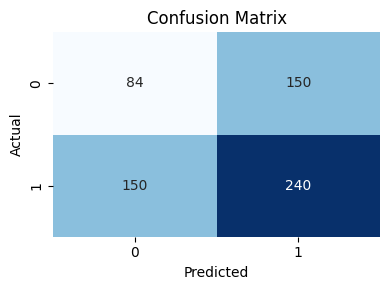

In [20]:
cm = confusion_matrix(test_generator.classes, (y_pred_weighted >= 0.65).astype(int))
labels = ["NORMAL", "PNEUMONIA"]

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
fig.tight_layout()
plt.show()